In [ ]:
# START OF BASE DATA IMPORTS
from google.colab import files

print("Please upload your CSV file.")
uploaded = files.upload()

file_path_1 = next(iter(uploaded))

Please upload your CSV file.


Saving visa_issuance.csv to visa_issuance (1).csv


In [ ]:
import pandas as pd

visa_df = pd.read_csv("visa_issuance.csv")

visa_df

,Country,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,3063,2723,1902,1552,1554,856,535,0,0,0
1,Albania,6600,8524,10001,12153,11489,6982,5524,14423,25483,25731
2,Algeria,11855,13704,11353,12888,12272,5137,691,11613,19240,19142
3,Angola,11330,6859,7670,7538,4904,1866,1394,3873,5446,5812
4,Argentina,249293,303897,360891,334430,222043,90187,39256,219375,288110,289971
...,...,...,...,...,...,...,...,...,...,...,...
163,Venezuela,239772,151014,47942,21290,4614,0,0,0,0,0
164,Vietnam,101221,104830,121118,123416,131093,64050,35212,92912,127380,144974
165,Yemen,656,0,0,0,0,0,0,0,0,0
166,Zambia,3752,4021,4365,4747,3736,1350,1049,6111,8081,3978


In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
dataset_path = kagglehub.dataset_download('justin2028/us-immigration-statistics-1980-2021')

100%|██████████| 1.42k/1.42k [00:00<00:00, 1.98MB/s]

Extracting files...


In [ ]:
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
files = os.listdir(dataset_path)
print(files)

immigrations_df = pd.read_csv(os.path.join(dataset_path, files[0]))

['US Immigration Statistics (Ver 1.14.26).csv']


In [ ]:
dataset_path = kagglehub.dataset_download('haejeg1/m-data')

100%|██████████| 172M/172M [00:01<00:00, 157MB/s]

Extracting files...


In [ ]:
files = os.listdir(dataset_path)
print(files)

immigrations_10_years_df = pd.read_csv(os.path.join(dataset_path, files[0]))
removals_df = pd.read_csv(os.path.join(dataset_path, files[1]))
net_migrations_df = pd.read_csv(os.path.join(dataset_path, files[2]))
arrests_df = pd.read_csv(os.path.join(dataset_path, files[3]))
# END OF BASE DATA IMPORTS

['immigrations.csv', 'removals.csv', 'net_migrations.csv', 'arrests.csv']


In [ ]:
# Get top 10 countries by removal in removal dataset
top_10_countries_by_removal = removals_df['Departure Country'].value_counts().head(10)

# Now we want to graph the top 10 countries by removal in removal dataset vs visa issuances within those countries


In [ ]:
import pandas as pd

visa_df['Country'] = visa_df['Country'].str.upper().str.strip()

top_removal_countries_df['Country'] = top_removal_countries_df['Country'].str.upper().str.strip()

visa_df_filtered = visa_df[visa_df['Country'].isin(top_removal_countries_df['Country'])]

visa_df_melted = visa_df_filtered.melt(id_vars=['Country'], var_name='Year', value_name='Visa Issuances')

visa_df_melted['Year'] = pd.to_numeric(visa_df_melted['Year'], errors='coerce')
visa_df_melted.dropna(subset=['Year'], inplace=True)
visa_df_melted['Year'] = visa_df_melted['Year'].astype(int)

removals_df['Departure Year'] = pd.to_datetime(removals_df['Departure Date']).dt.year

yearly_removals = removals_df.groupby(['Departure Country', 'Departure Year']).size().reset_index(name='Yearly Removals')

yearly_removals.rename(columns={'Departure Country': 'Country', 'Departure Year': 'Year'}, inplace=True)

yearly_removals['Country'] = yearly_removals['Country'].str.upper().str.strip()

top_countries_list = top_removal_countries_df['Country'].tolist()
yearly_removals_filtered = yearly_removals[yearly_removals['Country'].isin(top_countries_list)]

min_year_visa = visa_df_melted['Year'].min()
max_year_visa = visa_df_melted['Year'].max()

min_year_removals = yearly_removals_filtered['Year'].min()
max_year_removals = yearly_removals_filtered['Year'].max()

common_min_year = max(min_year_visa, min_year_removals)
common_max_year = min(max_year_visa, max_year_removals)
visa_df_common_years = visa_df_melted[(visa_df_melted['Year'] >= common_min_year) & (visa_df_melted['Year'] <= common_max_year)]
removals_df_common_years = yearly_removals_filtered[(yearly_removals_filtered['Year'] >= common_min_year) & (yearly_removals_filtered['Year'] <= common_max_year)]
merged_df_yearly = pd.merge(visa_df_common_years, removals_df_common_years, on=['Country', 'Year'], how='inner')
merged_df_yearly = merged_df_yearly.sort_values(by=['Country', 'Year'])
display(merged_df_yearly.head(10))

,Country,Year,Visa Issuances,Yearly Removals
0,BRAZIL,2015,922743,660
10,BRAZIL,2016,495962,1211
20,BRAZIL,2017,570497,1283
30,BRAZIL,2018,633601,1577
40,BRAZIL,2019,616862,1703
50,BRAZIL,2020,237178,1250
60,BRAZIL,2021,20503,2407
1,COLOMBIA,2015,357435,984
11,COLOMBIA,2016,386051,887
21,COLOMBIA,2017,346775,925


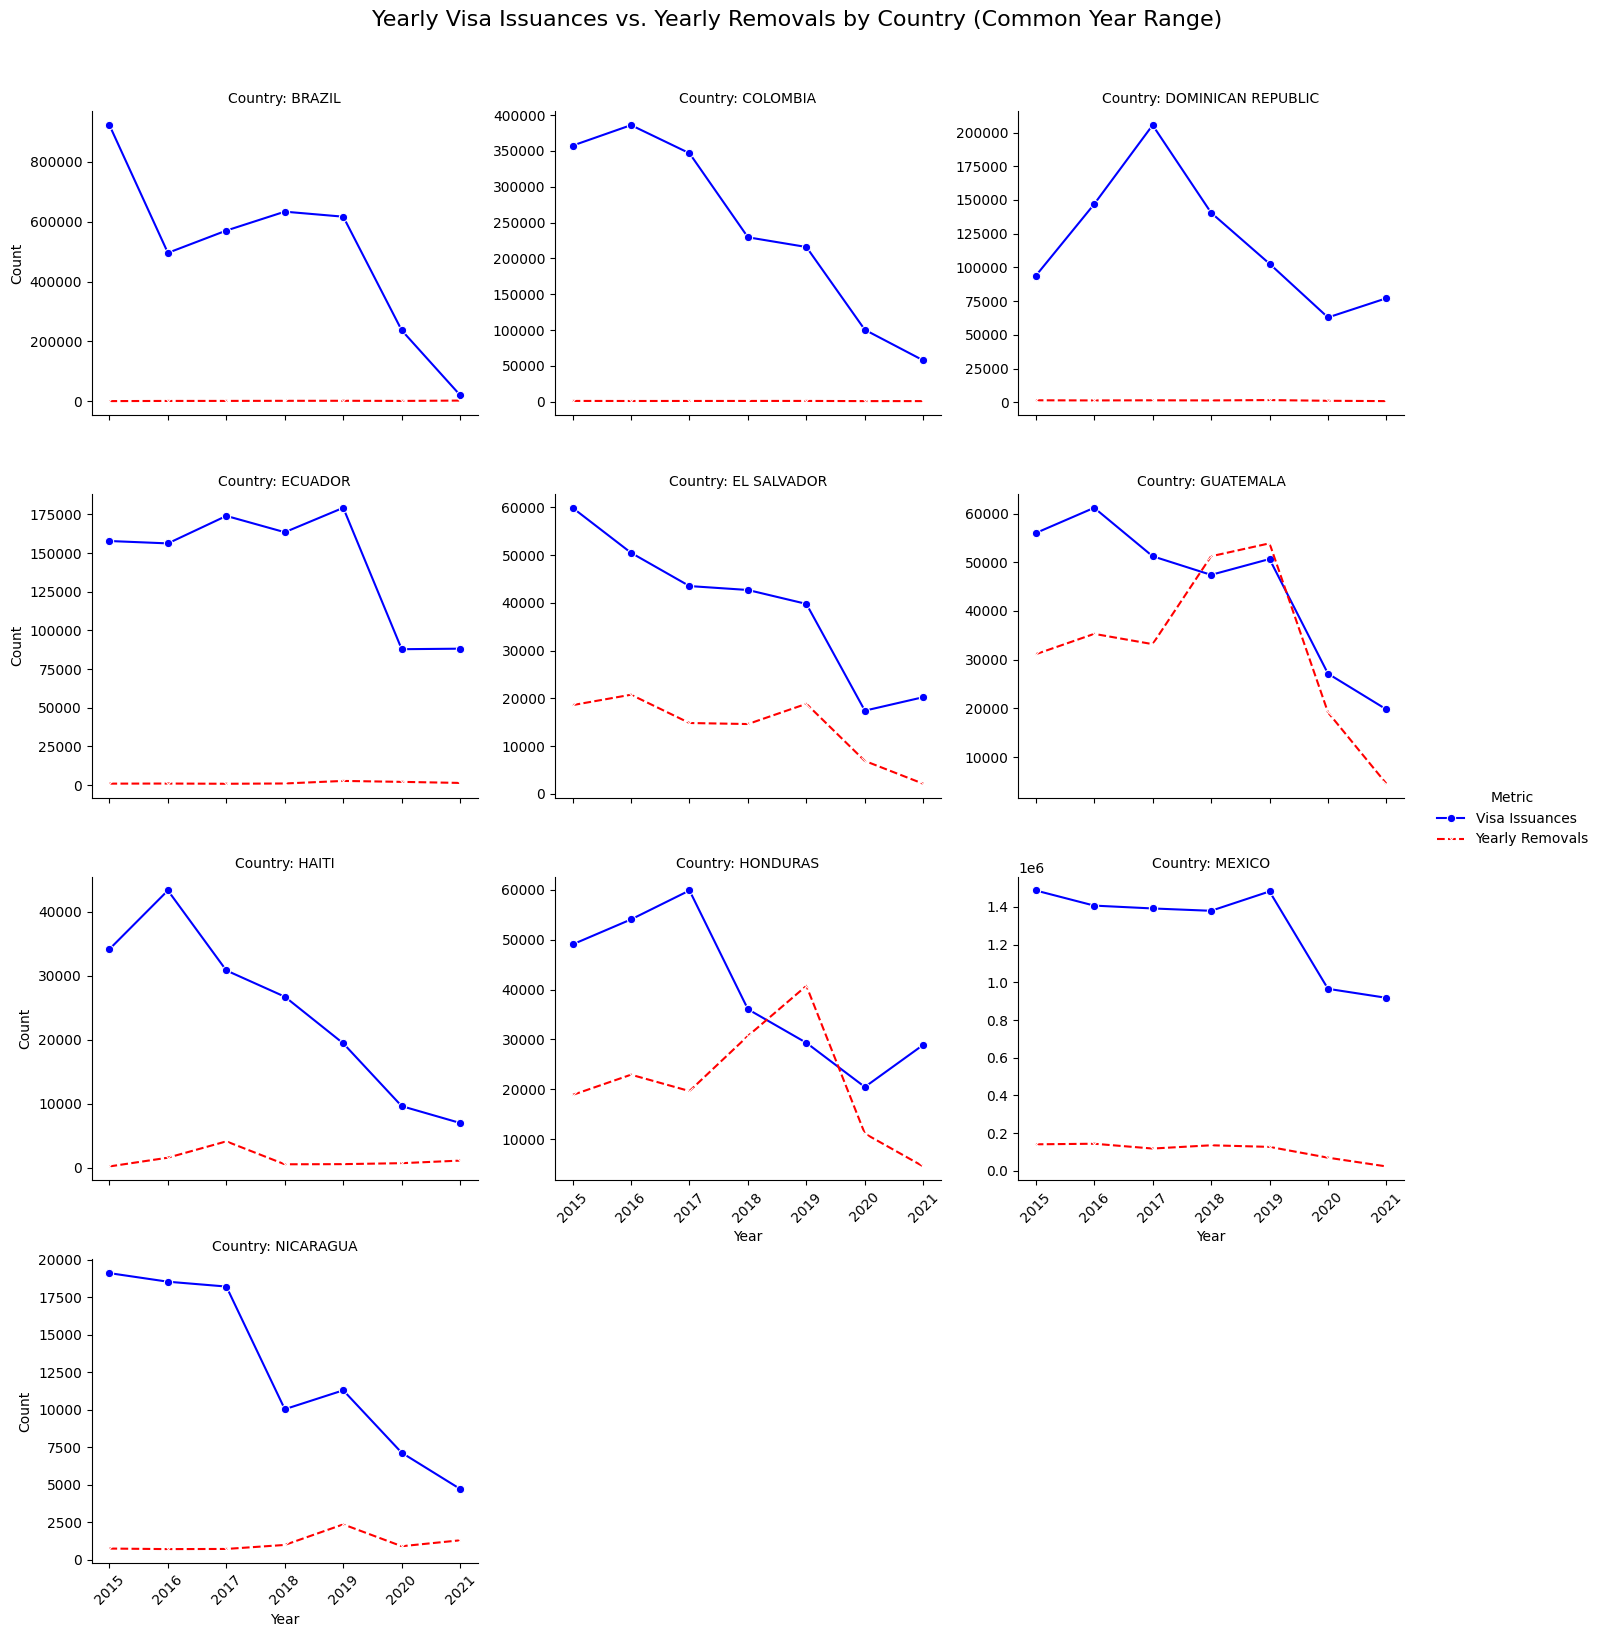

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.FacetGrid(merged_df_yearly, col="Country", col_wrap=3, height=4, aspect=1.2, sharey=False)

g.map(sns.lineplot, "Year", "Visa Issuances", marker="o", color='blue', label='Visa Issuances')

g.map(sns.lineplot, "Year", "Yearly Removals", marker="x", color='red', linestyle='--', label='Yearly Removals')

g.add_legend(title="Metric")

g.set_axis_labels("Year", "Count")
g.set_titles("Country: {col_name}")

years_to_label = merged_df_yearly['Year'].unique()
g.set(xticks=years_to_label)
g.set_xticklabels(labels=[str(year) for year in years_to_label], rotation=45) # Explicitly convert to string and set labels
plt.suptitle('Yearly Visa Issuances vs. Yearly Removals by Country (Common Year Range)', y=1.02, fontsize=16)
g.tight_layout()
plt.show()